#### **Credit Risk Analysis**

Dataset: Credit Risk Dataset 

Goal: Tìm ra ai là người có xu hướng nợ quá hạn (default), tại sao họ lại làm vậy, và làm thế nào để các quyết định cho vay trở nên đáng tin cậy hơn.

#### 1. Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#### 2. Exploratory Data Analysis (EDA)

2.1 Load Data

In [2]:
df = pd.read_csv('Credit Risk Dataset.xlsx - Credit Risk Data.csv',index_col= 0)

2.2 Initial Exploration

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
client_ID,,,,,,,,,,,,,,,,,,,,,
CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


In [4]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
client_ID,,,,,,,,,,,,,,,,,,,,,
CUST_32577,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,...,49.2827,-123.1207,Part-time,36,0.109434,15721.464520,0.406065,11,0.892039,1
CUST_32578,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,...,53.4808,-2.2426,Full-time,60,0.146875,29674.399350,0.394162,6,0.191486,0
CUST_32579,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,...,53.4808,-2.2426,Unemployed,24,0.460526,21098.865050,0.738143,11,0.678980,3
CUST_32580,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,...,37.7749,-122.4194,Self-employed,36,0.100000,26361.525750,0.275744,3,0.223460,1
CUST_32581,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,...,46.8139,-71.2080,Full-time,60,0.154167,9397.997205,0.377929,4,0.429304,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32581 entries, CUST_00001 to CUST_32581
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  gender                      32581 non-null  object 
 13  marital_status        

**Các biến được dùng:**

**client_ID:** Mã định danh duy nhất cho mỗi khách hàng

**person_age:** Tuổi của người nộp đơn (năm)

**person_income:** Thu nhập hàng năm của người nộp đơn (USD)

**person_home_ownership:** Tình trạng sở hữu nhà (THUÊ/SỞ HỮU/THẾ CHẤP)

**person_emp_length:** Thời gian làm việc (năm)

**loan_intent:** Mục đích vay (CÁ NHÂN, Y TẾ, GIÁO DỤC, v.v.)

**loan_grade:** Xếp hạng tín dụng được chỉ định cho khoản vay (A–G)

**loan_amnt:** Số tiền vay yêu cầu (USD)

**loan_int_rate:** Lãi suất vay (%)

**loan_status:** Tình trạng trả nợ (0 = không vỡ nợ, 1 = vỡ nợ)

**loan_percent_income:** Tỷ lệ phần trăm thu nhập được phân bổ cho việc trả nợ

**cb_person_default_on_file:** Người nộp đơn đã từng vỡ nợ trước đây hay chưa (Có/Không)

**cb_person_cred_hist_length:** Thời gian lịch sử tín dụng (năm)

**gender:** Giới tính của người nộp đơn (Nam/Nữ)

**marital_status:** Tình trạng hôn nhân (Độc thân/Đã kết hôn/Ly hôn/Góa phụ)

**education_level:** Trình độ học vấn (Trung học/Cử nhân/Thạc sĩ/Tiến sĩ)

**country:** Quốc gia cư trú

**state:** Tiểu bang/Tỉnh cư trú

**city:** Thành phố cư trú

**city_latitude:** Tọa độ vĩ độ của thành phố

**city_longitude:** Tọa độ kinh độ của thành phố

**employment_type:** Loại hình việc làm (Toàn thời gian/Bán thời gian/Tự kinh doanh/Thất nghiệp)

**loan_term_months:** Thời hạn vay (12, 24, 36, 60)

**loan_to_income_ratio:** Số tiền vay chia cho thu nhập của người nộp đơn

**other_debt:** giả định của người nộp đơn (USD)

**debt_to_income_ratio:** Tổng nghĩa vụ nợ chia cho thu nhập của người nộp đơn

**open_accounts:** Số tài khoản tín dụng đang mở

**credit_utilization_ratio:** Tỷ lệ sử dụng tín dụng (0–1)

**past_delinquencies:** Số lần nợ quá hạn/thanh toán trễ trong quá khứ

In [6]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,...,32581.000000,32581.000000,32581,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,...,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,...,NaN,NaN,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,...,NaN,NaN,19473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,...,45.407613,-63.805473,NaN,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,...,7.644809,46.615580,NaN,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,...,29.760400,-123.365600,NaN,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,...,40.712800,-96.797000,NaN,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,...,46.813900,-75.697200,NaN,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,...,51.507400,-3.943600,NaN,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies               0
dtype: int64

In [8]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
gender                         object
marital_status                 object
education_level                object
country                        object
state                          object
city                           object
city_latitude                 float64
city_longitude                float64
employment_type                object
loan_term_months                int64
loan_to_income_ratio          float64
other_debt                    float64
debt_to_income_ratio          float64
open_accounts                   int64
credit_utili

In [9]:
df.shape

(32581, 28)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['loan_status'] = df['loan_status'].astype('object')
df['loan_term_months'] = df['loan_term_months'].astype('object')

**Tổng quan dữ liệu:**

Dữ liệu gồm 32581 quan sát, 29 biến quan sát. Không có dòng bị trùng lặp

2.3 Univariate Analysis

In [12]:
object_col = []
numeric_col = []
for col in df:
    if df[col].dtypes == 'object':
        object_col.append(col)
    else:
        numeric_col.append(col)

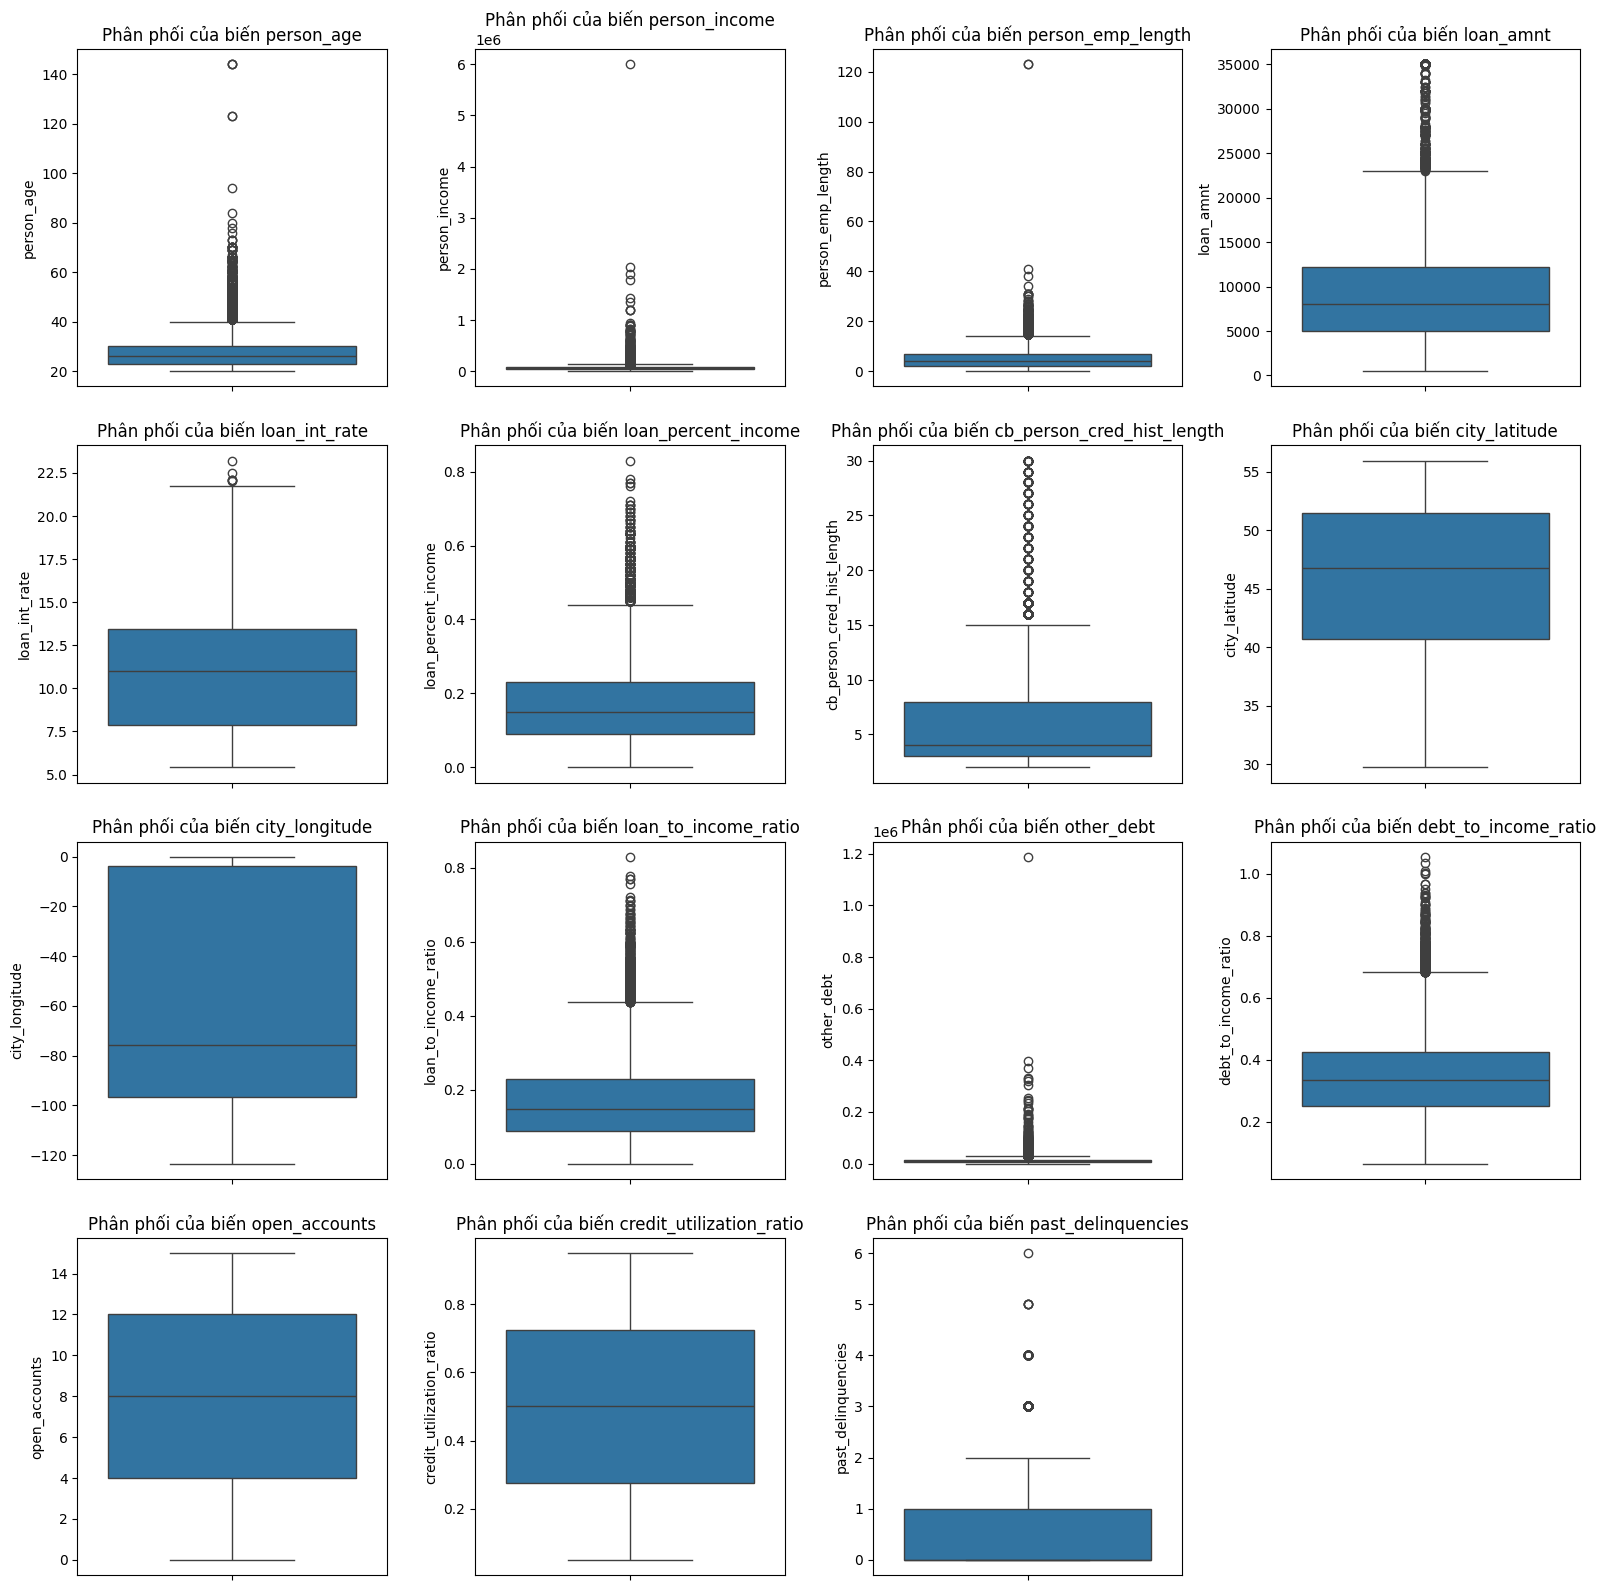

In [13]:
n_cols = 4
n_rows = (len(numeric_col)+n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows,n_cols,figsize = (16,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(numeric_col):
    sns.boxplot(y = df[col],ax = axes[i])
    axes[i].set_title(f'Phân phối của biến {col}')
for j in range(i + 1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 50]

In [15]:
df.shape

(31679, 28)

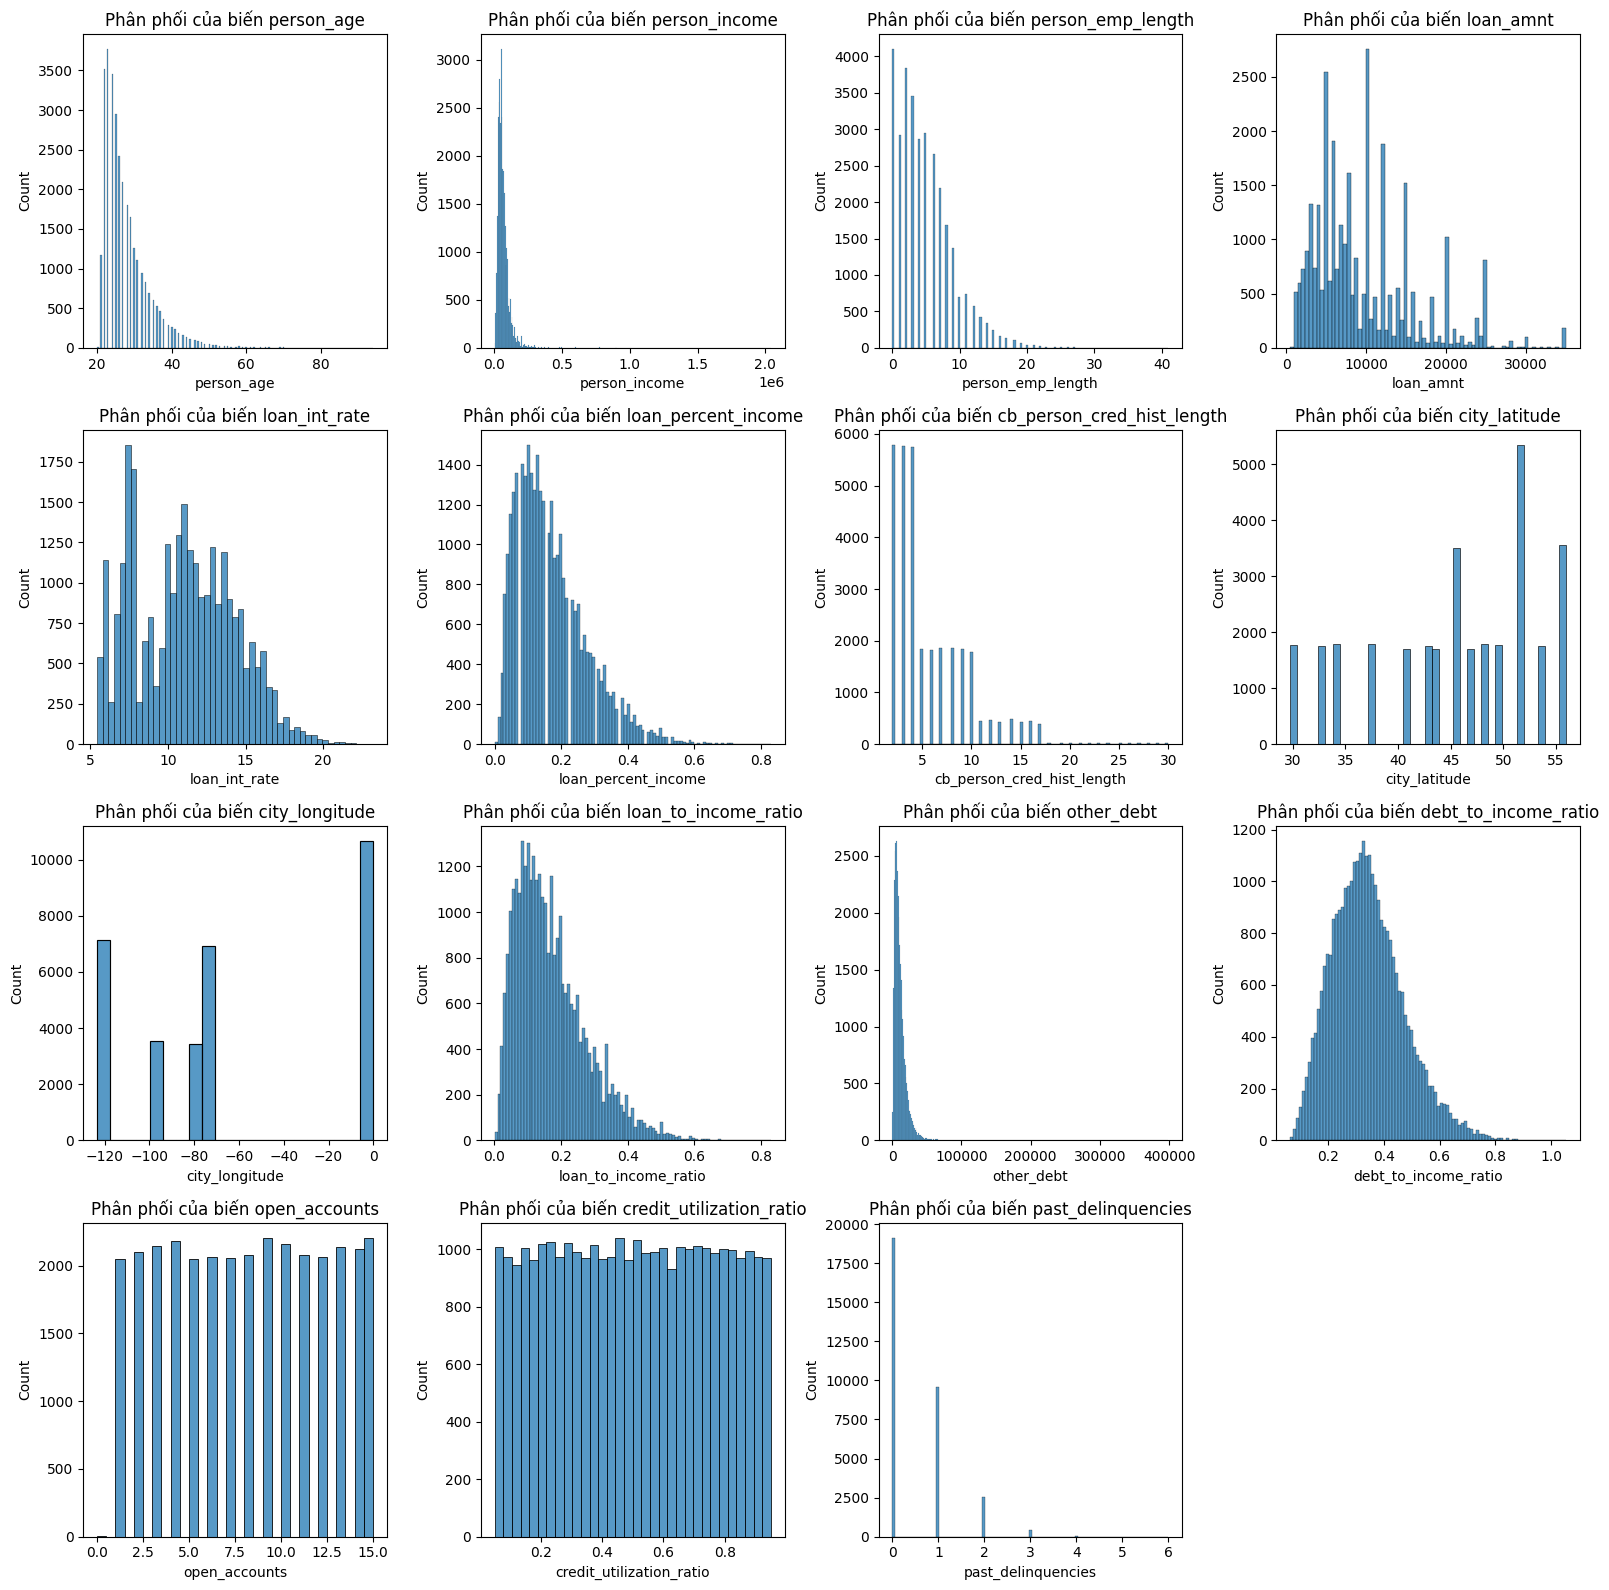

In [16]:
n_cols = 4
n_rows = (len(numeric_col)+n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows,n_cols,figsize = (16,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(numeric_col):
    sns.histplot(x = df[col],ax = axes[i])
    axes[i].set_title(f'Phân phối của biến {col}')
for j in range(i + 1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df['loan_int_rate']= df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
df['person_emp_length'] = df['person_emp_length'].fillna('median')

In [18]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
gender                        0
marital_status                0
education_level               0
country                       0
state                         0
city                          0
city_latitude                 0
city_longitude                0
employment_type               0
loan_term_months              0
loan_to_income_ratio          0
other_debt                    0
debt_to_income_ratio          0
open_accounts                 0
credit_utilization_ratio      0
past_delinquencies            0
dtype: int64

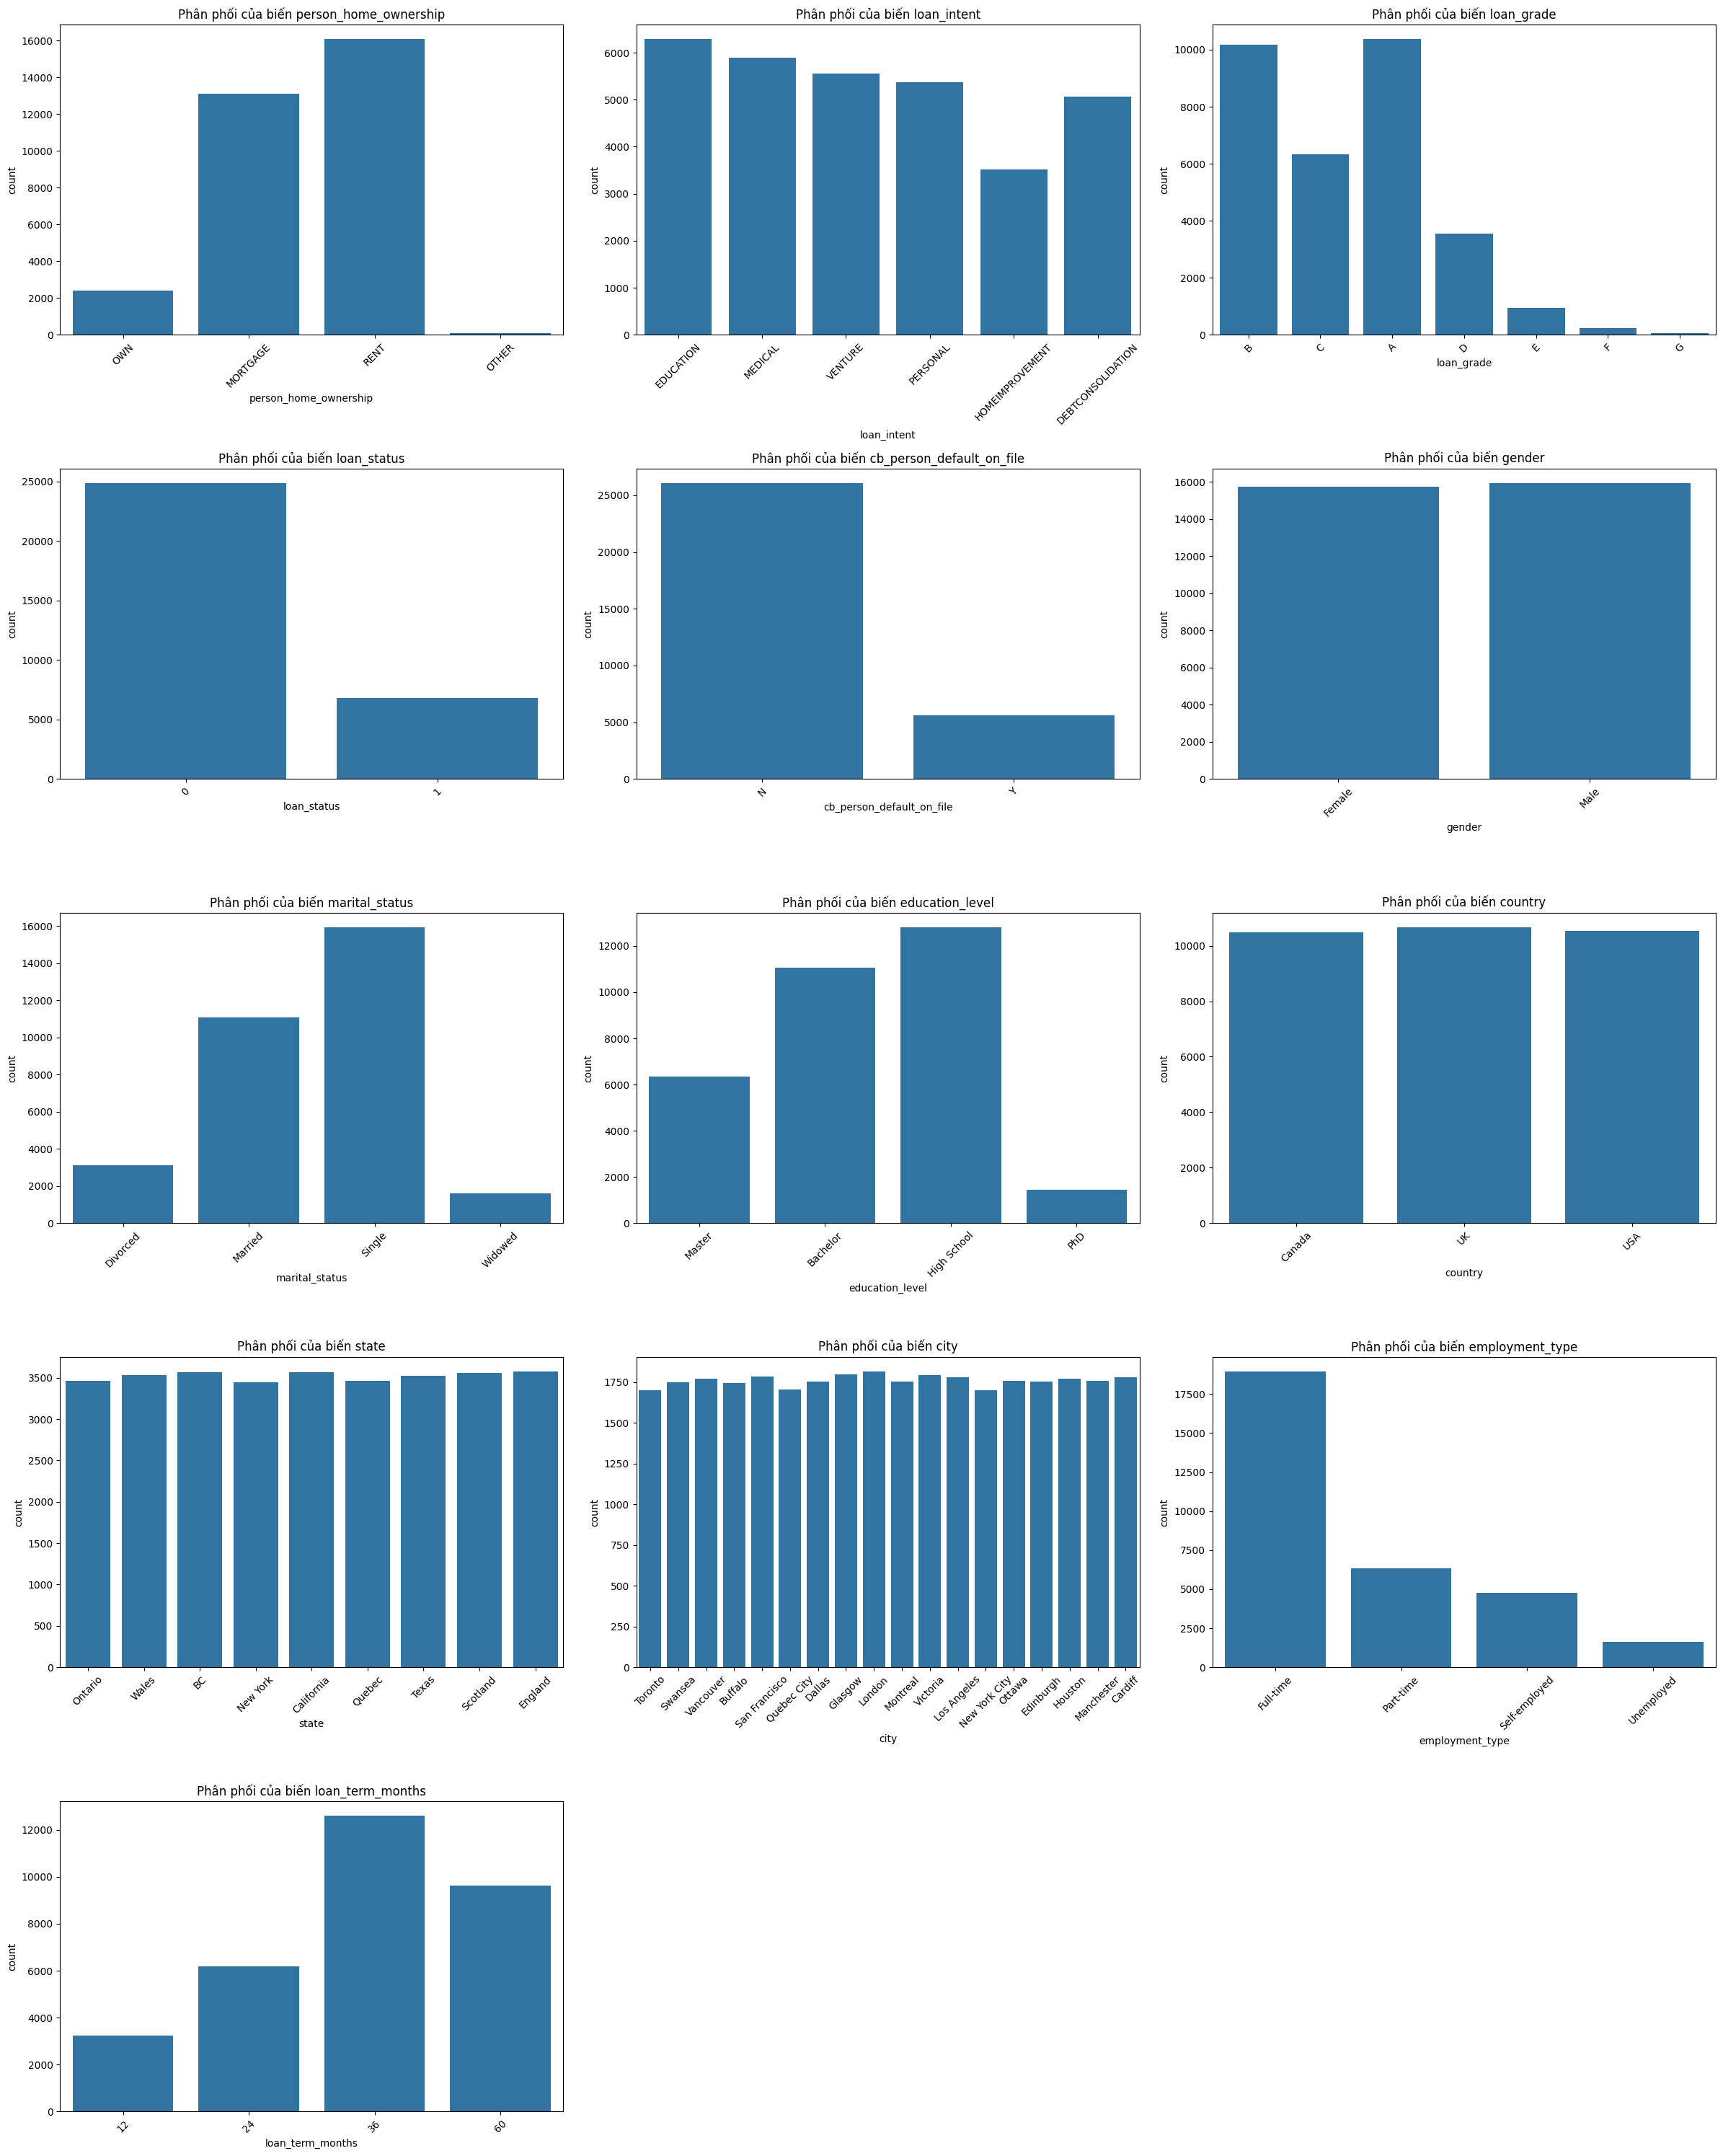

In [19]:
n_cols = 3
n_rows = (len(object_col)+n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows,n_cols,figsize = (24,6*n_rows))
axes = axes.flatten()
for i,col in enumerate(object_col):
    sns.countplot(data = df,x = col,ax = axes[i])
    axes[i].set_title(f'Phân phối của biến {col}')
    axes[i].tick_params(axis = 'x', rotation = 45)
for j in range(i + 1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

2.4 Multivariate Analysis

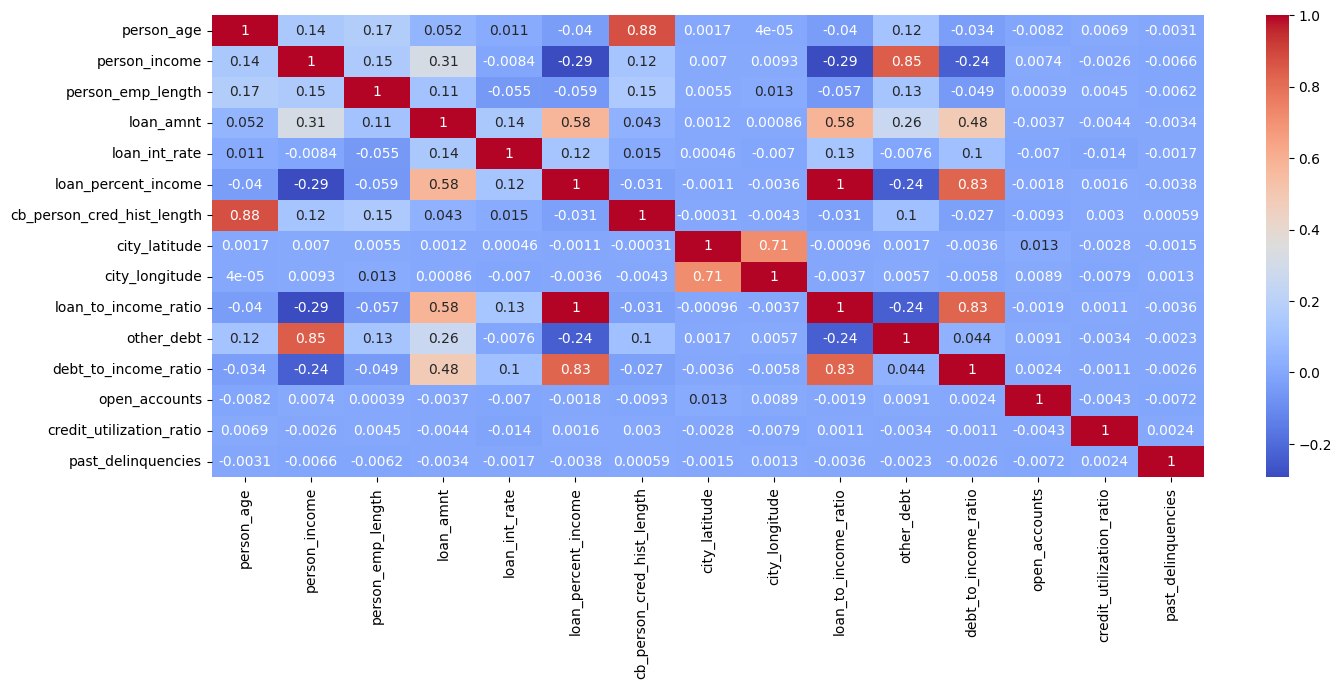

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize= (16,6))
sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.show()

In [21]:
df = df.drop('loan_to_income_ratio',axis = 1)
numeric_col.remove('loan_to_income_ratio')

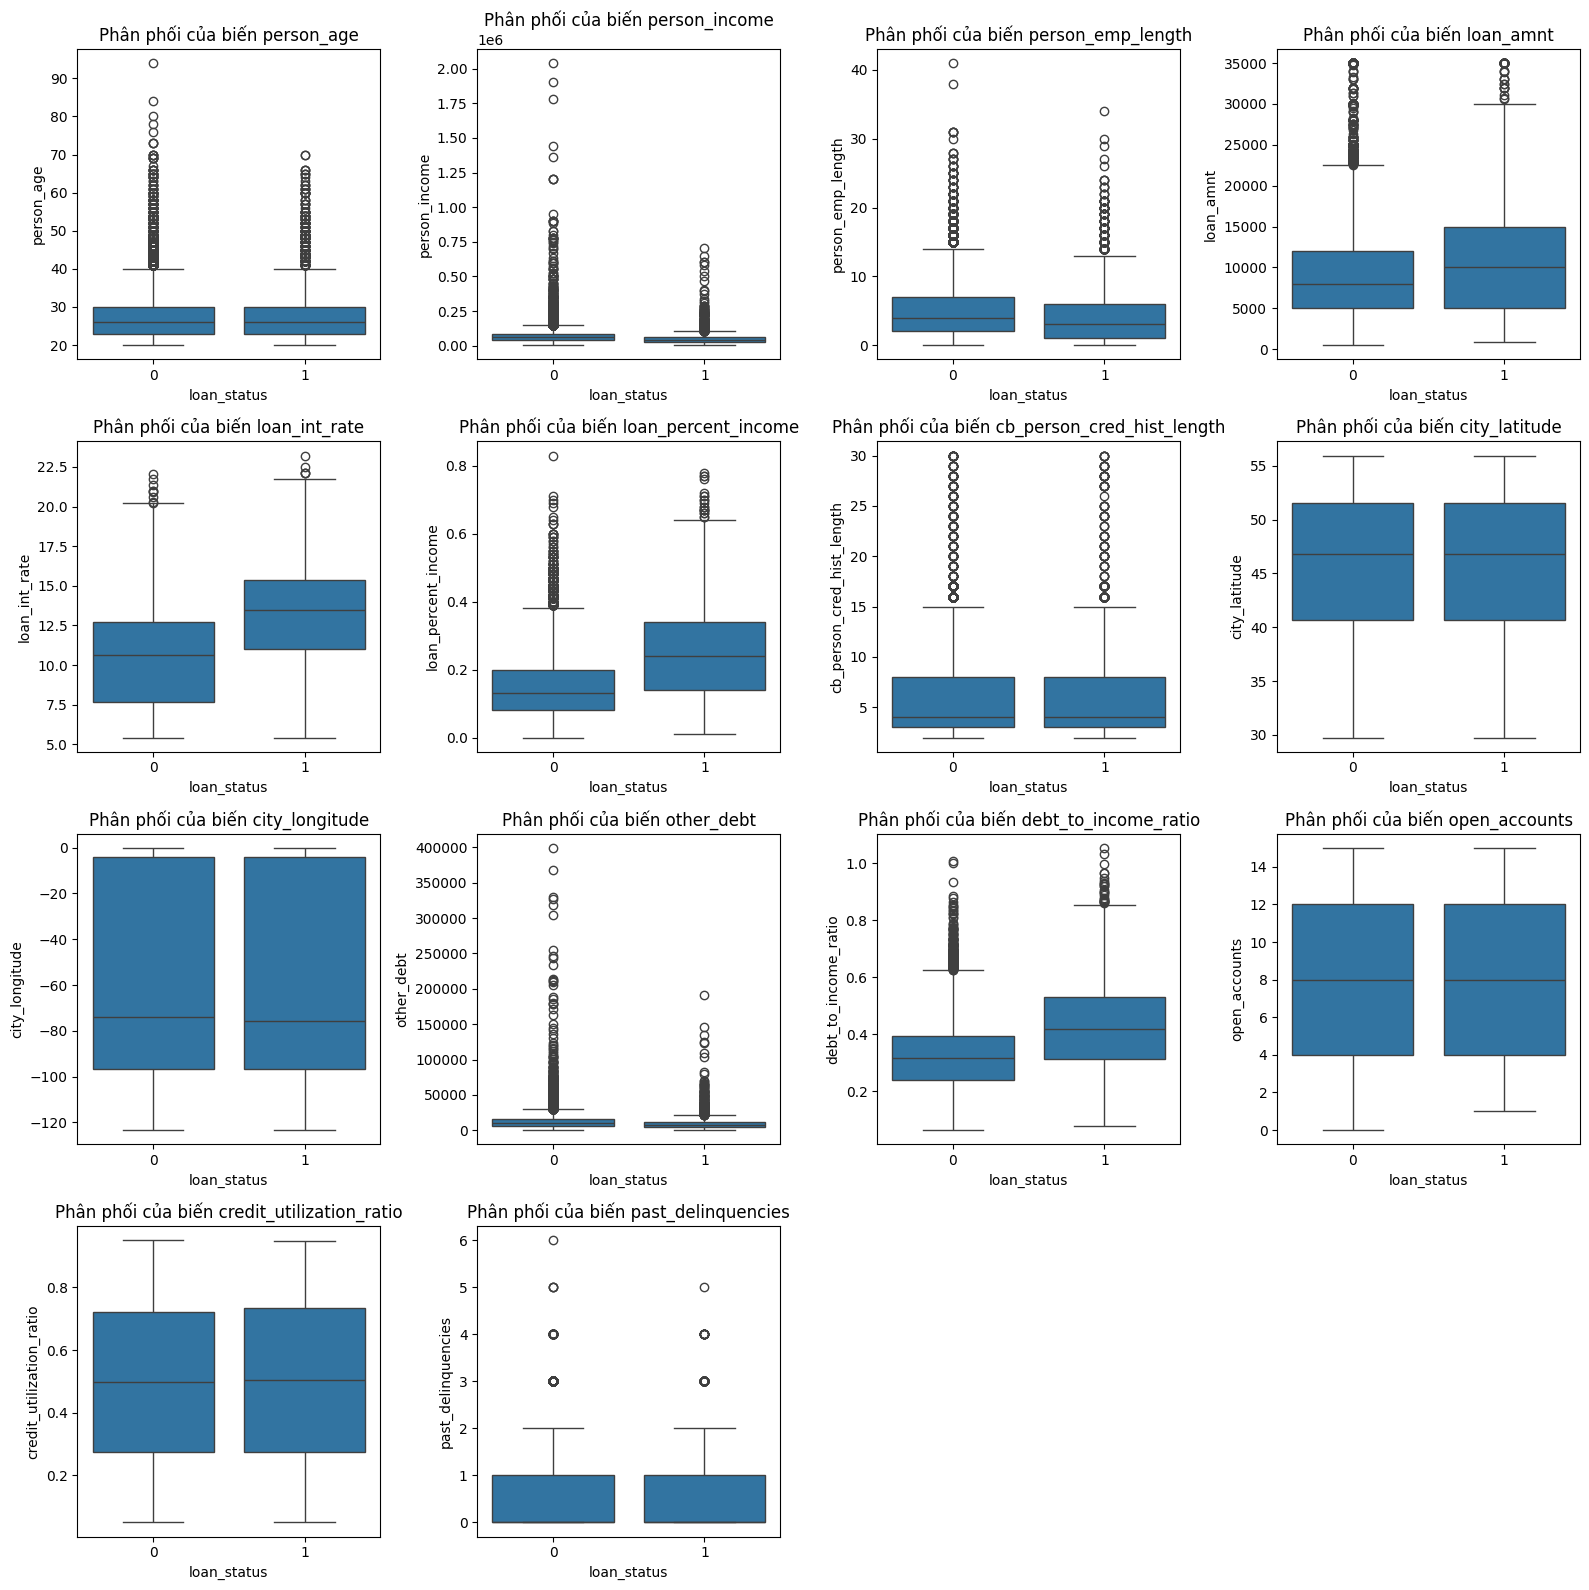

In [22]:
n_cols = 4
n_rows = (len(numeric_col)+n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows,n_cols,figsize = (16,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(numeric_col):
    sns.boxplot(y = df[col],x = df['loan_status'],ax = axes[i])
    axes[i].set_title(f'Phân phối của biến {col}')
for j in range(i + 1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**Insights from numerical analysis:**
1. Nhóm khách hàng vỡ nợ có mức lãi suất vay cao hơn hẳn so với nhóm không vỡ nợ.
2. Số tiền vay cũng là yếu tố tác động đến rủi ro vỡ nợ khi nhóm khách hàng vỡ nợ có phân phối số tiền vay rộng hơn và cũng nhỉnh hơn so với nhóm không vỡ nợ.
3. Tỉ lệ khoản vay/thu nhập cũng phản ánh sự tiêu cực khi nhóm vỡ nợ có khoản vay chiếm tỉ trọng quá lớn trong thu nhập sẽ dẫn đến rủi ro vỡ nợ cao hơn.
4. Tỉ lệ nợ/thu nhập cũng là yếu tố ảnh hưởng đến khả năng vỡ nợ khi khách hàng gánh tỉ lệ nợ trên thu nhập càng cao thì khả năng vỡ nợ càng cao.

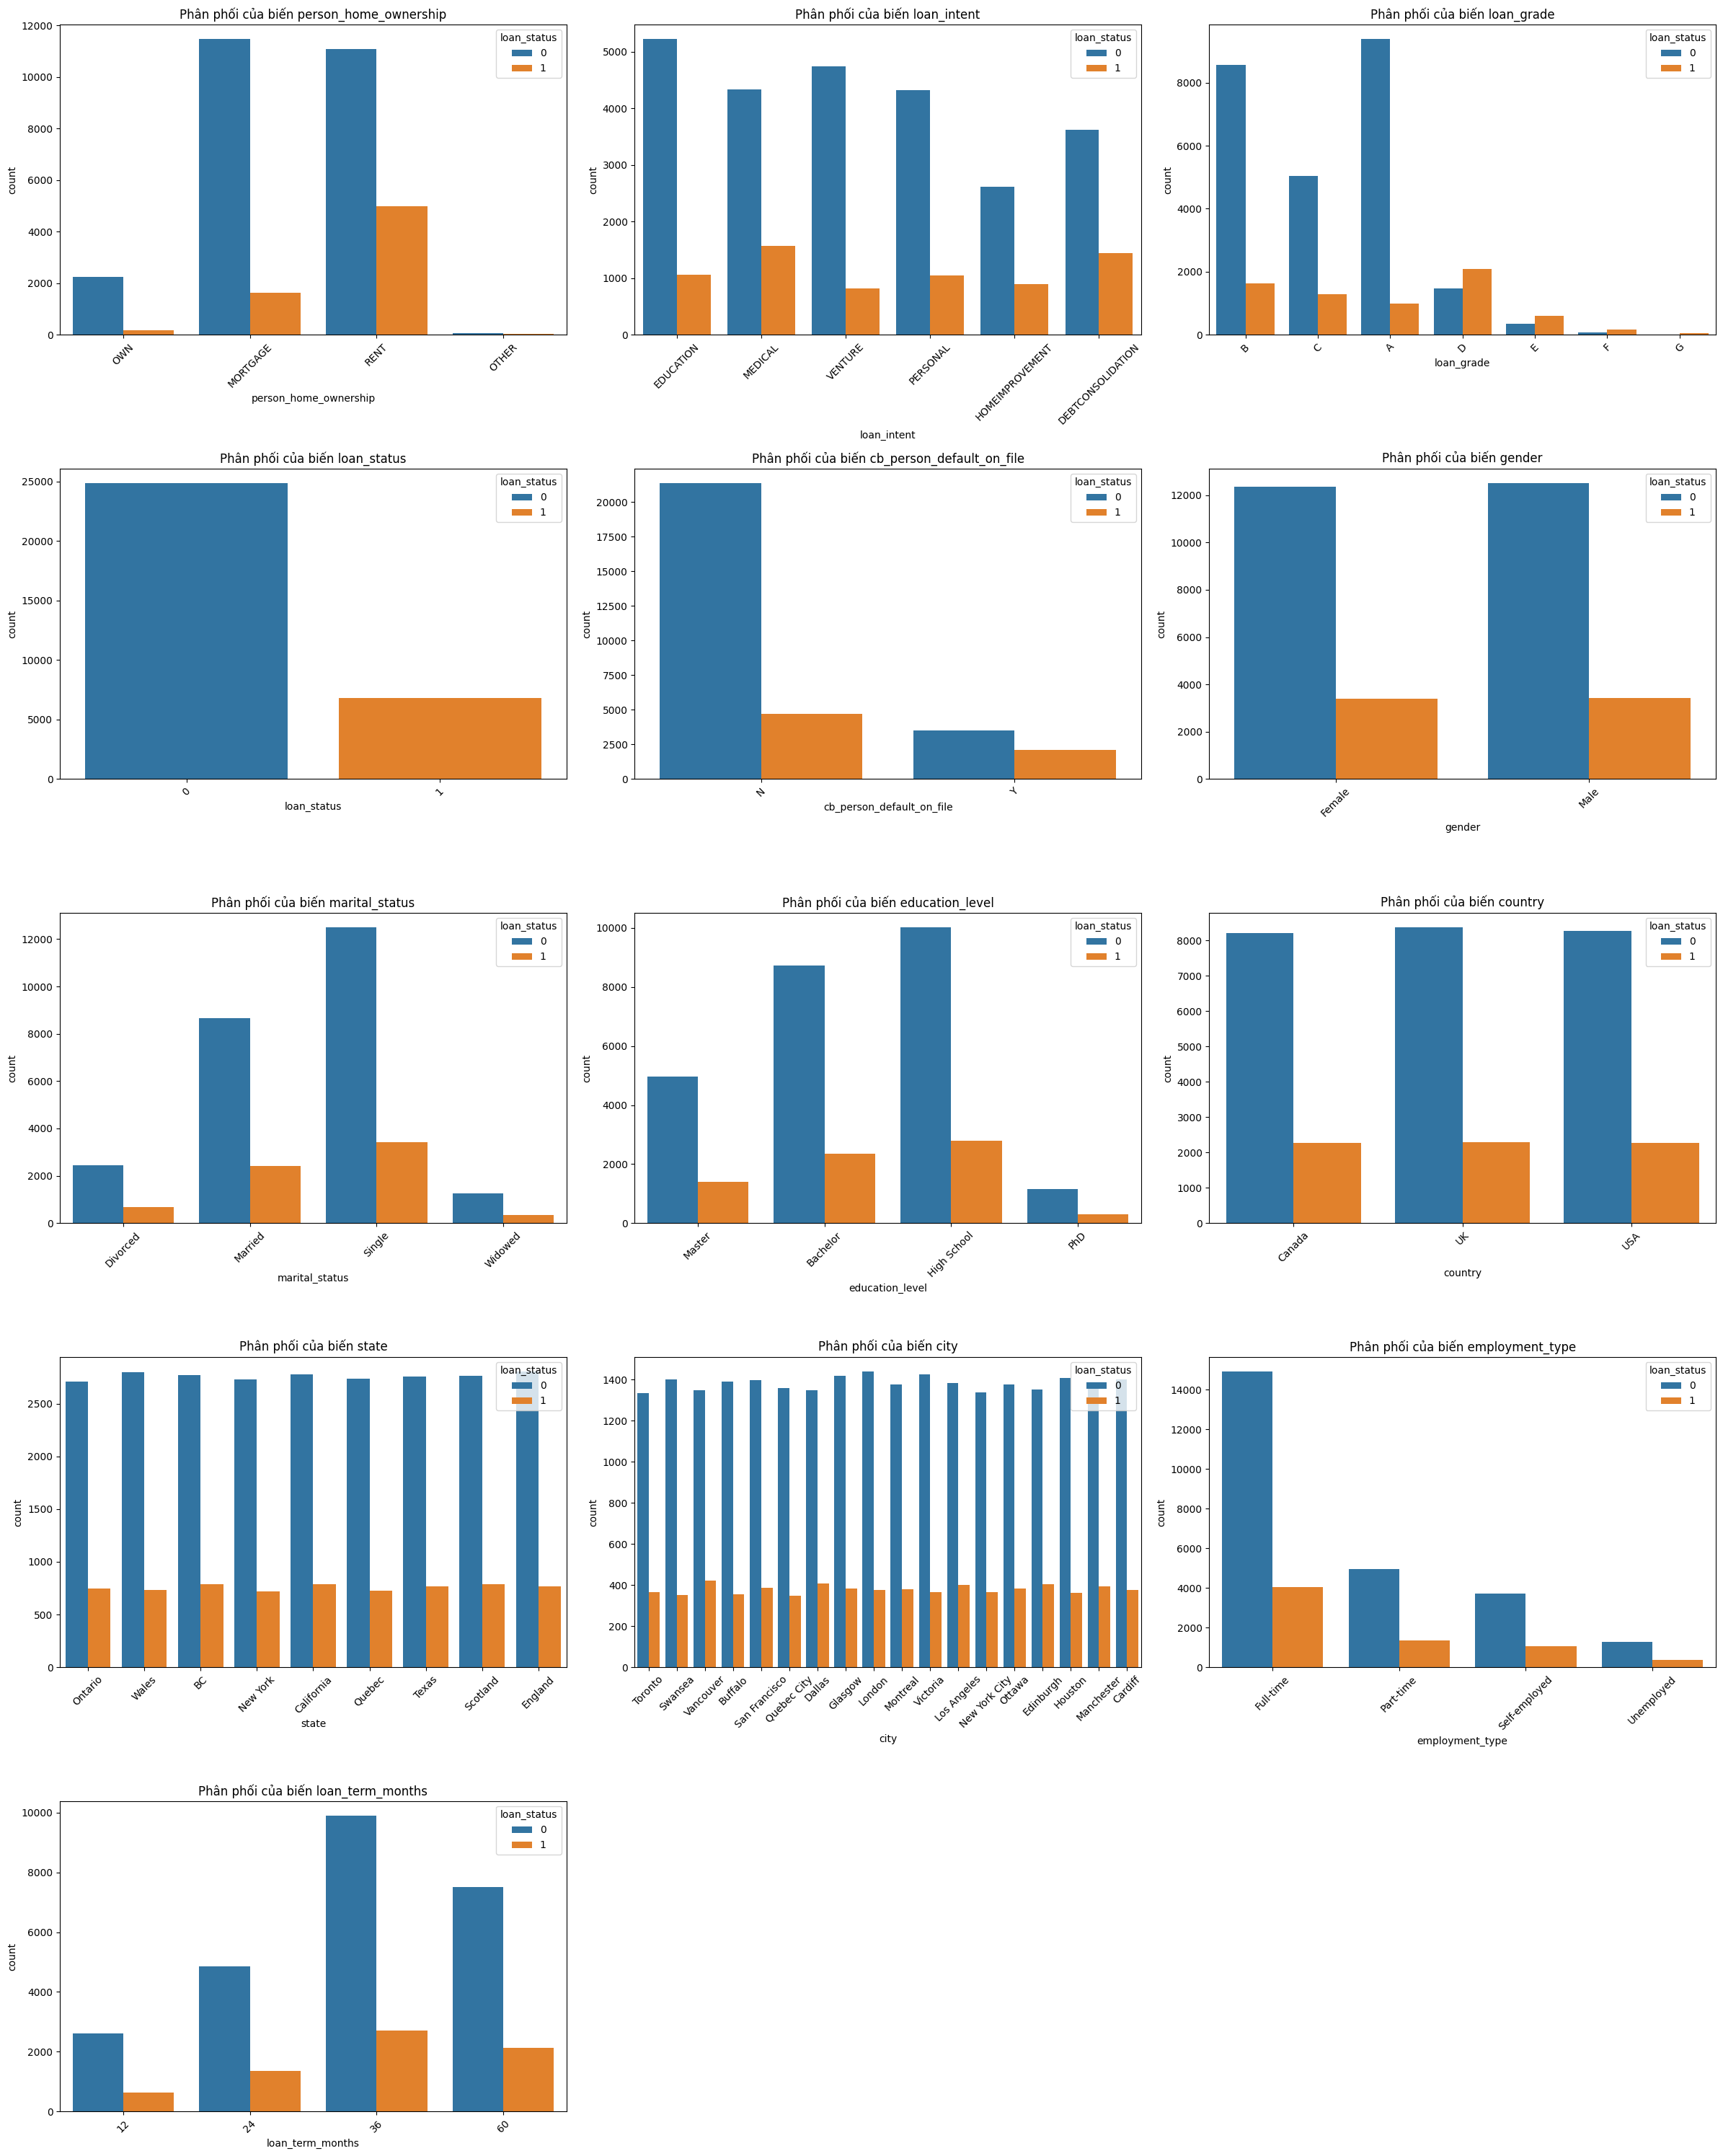

In [23]:
n_cols = 3
n_rows = (len(object_col)+n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows,n_cols,figsize = (24,6*n_rows))
axes = axes.flatten()
for i,col in enumerate(object_col):
    sns.countplot(data = df,x = col,hue = 'loan_status',ax = axes[i])
    axes[i].set_title(f'Phân phối của biến {col}')
    axes[i].tick_params(axis = 'x', rotation = 45)
for j in range(i + 1,len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**Insights from Categorical analysis:**
1. Các xếp hạng khoản vay cho thấy ở các hạng A,B,C tương ứng với mức lãi suất thấp thì tỷ lệ khách hàng vỡ nợ sẽ thấp. Khi mức lãi suất cao hơn tương ứng với các hạng khoản vay D,E,F,G thì tỷ lệ khách hàng vỡ nợ gần như vượt cao hơn tỷ lệ khách hàng không vỡ nợ.
2. Nhóm khách hàng đi thuê nhà thì có tỉ lệ vỡ nợ cao hơn rất nhiều so với nhóm thế chấp và nhóm sở hữu nhà trong đó nhóm sở hữu nhà có tỷ lệ vỡ nợ thấp nhất.
3. Lịch sử vỡ nợ cho thấy nhóm khách hàng đã từng vỡ nợ trong quá khứ có tỷ lệ vỡ nợ cao hơn hẳn nhóm có hồ sơ sạch.
4. Về mục đích vay nợ thì ta thấy mục đích y tế và mục đích gộp nợ sẽ có tỷ lệ vỡ nợ nhỉnh hơn so với vay để đầu tư hay giáo dục hoặc các lý do cá nhân.

In [24]:
%pip install pyodbc sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [25]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
server = "DESKTOP-96CU83L"
database = quote_plus("Project")
driver = quote_plus("ODBC Driver 17 for SQL Server")
engine = create_engine(f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes")
df.to_sql("credit_risk", engine, if_exists="replace", index=False)
pd.read_sql("SELECT TOP 5 * FROM credit_risk;", engine)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,city,city_latitude,city_longitude,employment_type,loan_term_months,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,Toronto,43.6532,-79.3832,Full-time,36,1607.802794,0.271646,10,0.585436,3
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,Swansea,51.6214,-3.9436,Full-time,36,2760.505633,0.860469,14,0.750732,0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,Vancouver,49.2827,-123.1207,Part-time,12,7155.286150,0.643592,15,0.379333,0
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,Buffalo,42.8864,-78.8784,Part-time,36,15626.153440,0.930628,4,0.228103,0
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,San Francisco,37.7749,-122.4194,Full-time,36,2211.741134,0.475933,10,0.827034,0


In [26]:
df.to_excel('credit_risk_new.xlsx')